# Consigna

Senoidal de frecuencia 
potencia normalizada, es decir energía (o varianza) unitaria
Se pide:

a) Sea <math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi>k</mi>
    <mn>0</mn>
  </msub>
  <mo>=</mo>
  <mo fence="false" stretchy="false">{</mo>
  <mi>N</mi>
  <mrow data-mjx-texclass="ORD">
    <mo>/</mo>
  </mrow>
  <mn>4</mn>
  <mo>,</mo>
  <mi>N</mi>
  <mrow data-mjx-texclass="ORD">
    <mo>/</mo>
  </mrow>
  <mn>4</mn>
  <mo>+</mo>
  <mn>0.25</mn>
  <mo>,</mo>
  <mi>N</mi>
  <mrow data-mjx-texclass="ORD">
    <mo>/</mo>
  </mrow>
  <mn>4</mn>
  <mo>+</mo>
  <mn>0.5</mn>
  <mo fence="false" stretchy="false">}</mo>
</math>
. Notar que a cada senoidal se le agrega una pequeña desintonía respecto a  <math xmlns="http://www.w3.org/1998/Math/MathML">
  <msub>
    <mi mathvariant="normal">&#x394;</mi>
    <mi>f</mi>
  </msub>
</math>
. Graficar las tres densidades espectrales de potencia (PDS's) y discutir cuál es el efecto de dicha desintonía en el espectro visualizado.

b) Verificar la potencia unitaria de cada PSD. En base a la teoría estudiada, ¿cuál es la razón por la cual una señal senoidal tiene un espectro (PSD) tan diferente respecto a otra de muy pocos Hertz de diferencia?



# Funciones Previas

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

In [194]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    xx = np.array(xx).reshape(nn,1)
    tt = tt.reshape(nn,1)

    return xx, tt

def mi_funcion_cuadrada(vmax = 1, dc = 0, ff = 1, duty = .5, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray] :
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.where(tt % (1/ff) < (1/ff) * duty, 1, -1)
    xx = vmax * xx + dc
    #signal.square(2* np.pi * ff* tt, duty)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_funcion_triangular(vmax = 1, dc = 0, ff = 1, nn = 1, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop= nn*ts, step=ts)
    T = 1/ff

    xx = [((vmax/T) * (i%T) + dc) for i in tt]
    #signal.sawtooth(2* np.pi * ff* tt, 0.5)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    '''noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
        Generates Gaussian noise, with variance var and zero mean.

        Note: This distribution corresponds to "white noise". (Extracted from ASYS notes, Stochastic process - White Noise)
    '''
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.random.normal(loc=0, scale=np.sqrt(var), size=nn)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_sen_ruidosa( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000, snr = 20) -> tuple[np.ndarray,np.ndarray]:
    xx, tt = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=nn, fs=fs)
    pot_signal = np.mean(xx**2)
    var_noise = pot_signal / (10**(snr/10))  # Calculando potencia de señal conocida "senoidal"
    # var_noise = power(xx) / (10**(snr/10))    # Lo mismo, calculando potencia por definicion
    
    noise, _ = noise_generator(var_noise, nn, fs)
    xx = xx + noise

    return xx, tt

def power(x: np.ndarray) -> float:
    '''power(x: np.ndarray) -> float:
        Returns the power of the signal x, defined as the mean of the square of the Voltage signal. 
    '''
    return np.mean(np.mean(x)**2)

def snr(signal: np.ndarray, noise: np.ndarray) -> float:
    return 10 * np.log10(np.mean(signal**2) / np.mean(noise**2))

def mi_adc(xx, Vfs, bits=4):
    '''mi_adc
    Quantizes the signal xx like an ADC with Vfs and bits.
    xx: Signal to be quantized.
    Vfs: ADC [0, Vfs]
    bits: Number of bits of the ADC.
    ''' 
    q = Vfs/(2**bits) 
    xq = np.round(xx/q) * q
    vmax =  q*(2**(bits-1)-1)
    vmin = -q*2**(bits-1)

    np.clip(xq, vmin, vmax, out=xq)
    #xq[xq > vmax] = vmax
    #xq[xq < vmin] = vmin
    return xq

def autocorrelate(xx: np.ndarray) -> np.ndarray:
    xx = np.asarray(xx).flatten()

    autocorr = np.correlate(xx, xx, mode='full')/xx.size        # Normalizated to size. Gives the true values of the autocorrelation
    autocorr = autocorr[autocorr.size//2:]                      # Only keep non negative values
    autocorr = autocorr.reshape(-1,1)                           # Reshape to column vector (standard of PDS)
    return autocorr

def mod_db(xx: np.ndarray) -> np.ndarray:
    return 20*np.log10(np.abs(xx))

def mod_dbw(xx: np.ndarray) -> np.ndarray:
    return 10*np.log10(np.abs(xx))

def freq_axis(xx: np.ndarray, fs: float) -> np.ndarray:
    '''freq_axis
    
    Equal to np.fft.fftfreq. It generates the correct freq axis for the fft algorithm.
    Axis has the form:
    [0, △f, 2△f, ..., fs/2, -fs/2, -(fs/2-△f), ..., -△f]
    Note: the positive half always starts with 0. The negative half always starts with -fs/2, so, the negative half has one extra value if the length of the signal is even.
    xx: signal to generate the axis for. Only the length is used.
    fs: sampling frequency
    '''
    nn = xx.shape[0]
    half = np.arange(0, fs/2, fs/nn)
    ff = np.concatenate((half, -half[::-1] - fs/nn))
    ff = ff[:nn]
    return ff.reshape(-1,1)

# Respuesta

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

In [195]:
def check_est(xx, f0, fs, N):
    '''check_est(xx, f0, fs, N):
        Checks the estimation of the amplitude and frequency of a signal xx, given the true frequency f
        xx: signal to check the estimation of amplitude and frequency. It is expected to be a 2D array with shape (N, ...).
        f0: true frequency of the signal. It is expected to be a scalar.
        fs: sampling frequency of the signal. It is expected to be a scalar.
        N: number of points to calculate the fft. It is expected to be a scalar.
    '''
    N_real = xx.shape[0]
    xx_fft = np.fft.fft(xx, N, axis=0) / N_real
    xx_fft_abs = np.abs(xx_fft)

    a_estimado = 2 * xx_fft_abs[int(f0*N/fs), :]
    freq_estimado = np.argmax(xx_fft_abs[0:N//2, :], axis=0)*fs/N

    return xx_fft_abs, a_estimado, freq_estimado

## Prueba 1:

- Señal con 3dB de ruido, con una frecuencia variable uniforme de +-2 
- Se utilizan 4 ventanas distintas.
- Se calcula el sesgo y varianza de una estimación de energía/amplitud y de frecuencia.

In [196]:
from scipy import signal
####### VALORES 
N = 2000
fs = 2000
vmax = 2**.5
snr = 3
f0 = fs/4

cant_muestras = 200

####### VENTANAS 
windows = ["rectangular", "flattop", "blackman-harris", "hamming"]
win = {}
win[windows[0]] = np.ones(N).reshape(-1,1)
win[windows[1]] = signal.windows.flattop(N).reshape(-1,1)
win[windows[2]] = signal.windows.blackmanharris(N).reshape(-1,1)
win[windows[3]] = signal.windows.hamming(N).reshape(-1,1)

matrix_win = {}
for key in win.keys():
    win[key] = win[key]/np.mean(win[key])
    matrix_win[key] = np.tile(win[key], (1, cant_muestras))

####### SEÑAL
fr = np.random.uniform(-2,2, cant_muestras)
freq = fr + f0

xx = [mi_sen_ruidosa(vmax=vmax, ff=freq[i], nn=N, fs=fs, snr=snr)[0] for i in range(cant_muestras)]
xx = np.hstack(xx)
xx


array([[ 0.07531264, -0.28315763, -0.29295572, ...,  0.28676219,
         0.22550671,  0.25604989],
       [ 2.07118677,  1.45872064,  1.24709   , ...,  1.96623407,
         0.41828689,  1.99632296],
       [-0.07030877, -0.64539196,  0.0576439 , ..., -0.98052968,
        -0.86788101, -0.55564847],
       ...,
       [-1.37250903, -0.84735041,  0.19224032, ..., -0.90110706,
        -0.96994636,  0.07385382],
       [-1.57805249,  0.19620571, -1.569961  , ...,  0.71036357,
        -0.49520738,  1.09942913],
       [ 0.43171612,  0.94565588, -2.2686514 , ...,  1.08501966,
         1.48723444,  1.27670031]], shape=(2000, 200))

In [197]:
####### ESTIMADORES 
a_est = {}
freq_est = {}
xx_fft_abs = {}


for key in matrix_win.keys():
	xx_ventaneado = xx * matrix_win[key]
	xx_fft_abs[key], a_est[key], freq_est[key] = check_est(xx_ventaneado, f0, fs, N)


freq_est["rectangular"]


array([499., 500., 500., 499., 500., 501., 501., 501., 499., 499., 501.,
       500., 500., 501., 500., 498., 501., 500., 501., 498., 500., 499.,
       499., 498., 502., 500., 499., 500., 499., 501., 501., 501., 502.,
       499., 498., 499., 498., 499., 501., 501., 500., 500., 501., 499.,
       501., 499., 499., 501., 499., 501., 498., 500., 501., 502., 501.,
       500., 499., 501., 499., 502., 499., 502., 499., 501., 499., 502.,
       499., 498., 499., 501., 500., 499., 498., 498., 502., 498., 501.,
       499., 501., 500., 501., 501., 498., 499., 499., 500., 498., 498.,
       499., 498., 502., 500., 502., 499., 499., 499., 501., 501., 499.,
       502., 499., 501., 500., 499., 500., 501., 501., 499., 500., 500.,
       498., 500., 499., 499., 499., 501., 501., 502., 498., 501., 499.,
       501., 499., 499., 501., 500., 501., 499., 500., 501., 499., 501.,
       501., 502., 498., 499., 502., 499., 500., 500., 501., 498., 501.,
       499., 501., 498., 500., 501., 499., 501., 50

In [198]:
##### Cálculo de sesgo
sesgo_a = {}
sesgo_freq = {}
var_a = {}
var_freq = {}

for key in a_est.keys():
    sesgo_a[key] = np.mean(vmax - a_est[key])
    var_a[key] = np.var(vmax - a_est[key])
    sesgo_freq[key] = np.mean(freq - freq_est[key])
    var_freq[key] = np.var(freq - freq_est[key])


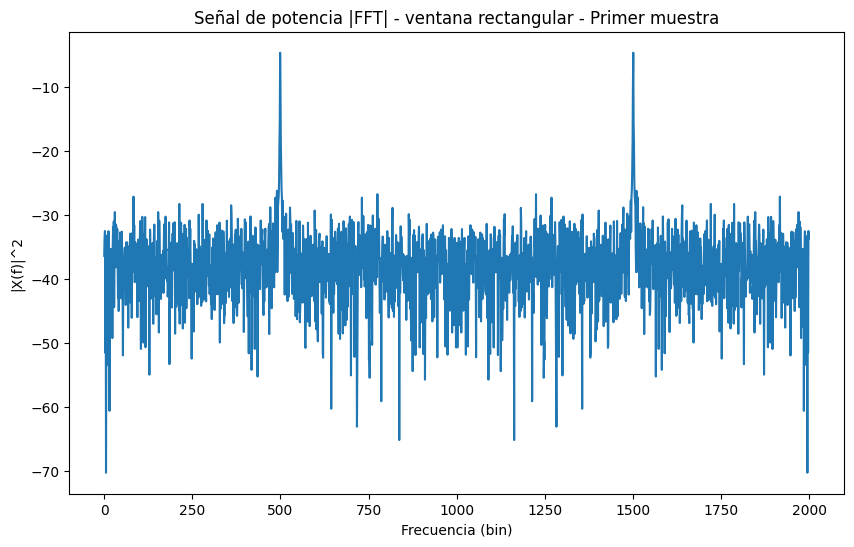

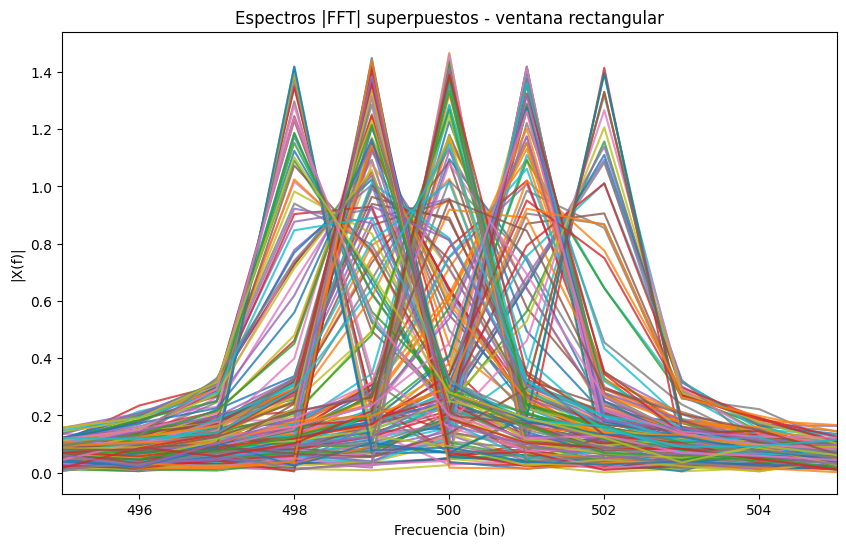

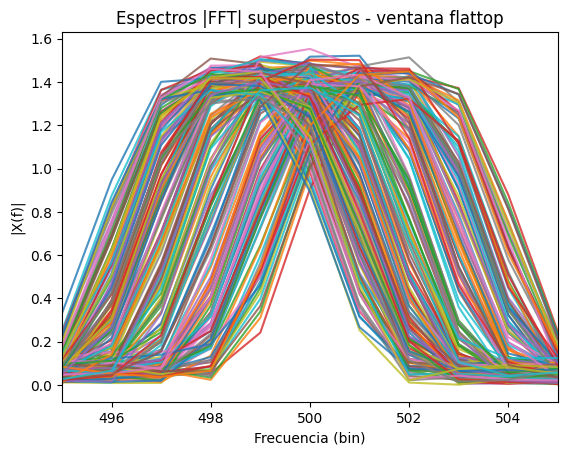

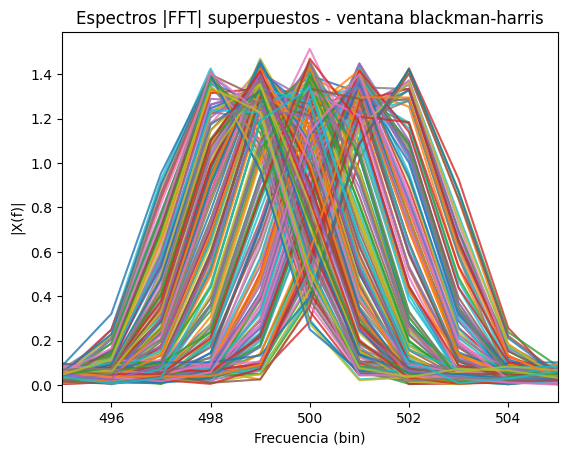

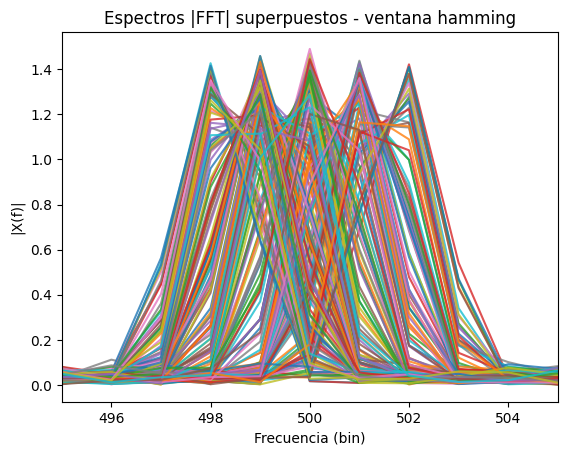

In [199]:
##### Check de primer muestra
PXX = xx_fft_abs["rectangular"][:,0]**2
plt.figure(figsize=(10,6))
plt.plot(10*np.log10(PXX))
plt.title("Señal de potencia |FFT| - ventana rectangular - Primer muestra")
plt.xlabel("Frecuencia (bin)")
plt.ylabel("|X(f)|^2")
plt.show()


##### Gráfico de espectros superpuestos
plt.figure(figsize=(10,6))
for key in xx_fft_abs.keys():
    for i in range(xx_fft_abs[key].shape[1]):
        plt.plot(2*xx_fft_abs[key][:, i], alpha=0.8)
    plt.xlim(f0*0.99, f0*1.01)
    plt.title(f"Espectros |FFT| superpuestos - ventana {key}")
    plt.xlabel("Frecuencia (bin)")
    plt.ylabel("|X(f)|")
    plt.show()


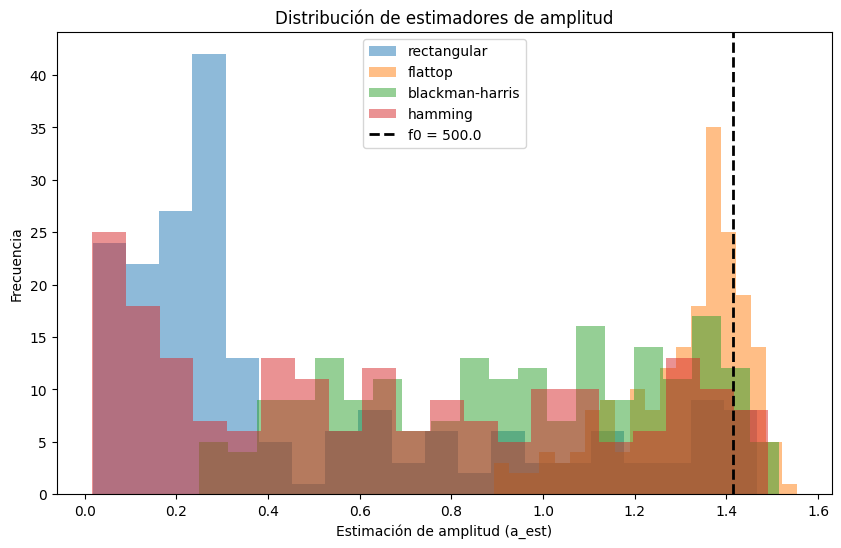

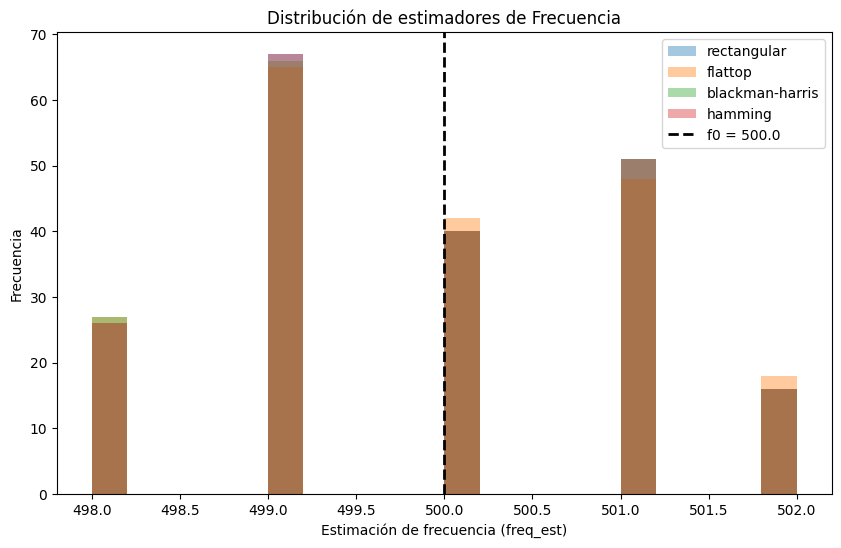


Ventana         |        Sesgo a      Varianza a      Sesgo freq   Varianza freq
rectangular     |          0.941           0.182          0.0104          0.0854 
flattop         |          0.106          0.0193         0.00539           0.139 
blackman-harris |          0.481           0.117          0.0154          0.0853 
hamming         |          0.761           0.212          0.0104          0.0854 


In [200]:
##### Histograma para cada ventana
fig, ax = plt.subplots(figsize=(10,6))

bins = 20 
alpha = .5

for key in a_est.keys():
    ax.hist(a_est[key], bins=bins, alpha=alpha, label=key)
ax.axvline(vmax, linestyle="--", linewidth=2, label=f"f0 = {f0}", color="black")

ax.set_xlabel("Estimación de amplitud (a_est)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de estimadores de amplitud")
ax.legend()
plt.show()


##### Histograma para cada ventana
fig, ax = plt.subplots(figsize=(10,6))

bins = 20 
alpha = .4
for key in freq_est.keys():
    ax.hist(freq_est[key], bins=bins, alpha=alpha, label=key)

ax.axvline(f0, linestyle="--", linewidth=2, label=f"f0 = {f0}", color="black")

ax.set_xlabel("Estimación de frecuencia (freq_est)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de estimadores de Frecuencia")

ax.legend()
plt.show()


print("\n" + "="*80)
print(f"{'Ventana':<15} |{'Sesgo a':>15} {'Varianza a':>15} {'Sesgo freq':>15} {'Varianza freq':>15}")
print("="*80)
for key in sesgo_a.keys():
    print(
        f"{key:<15} |"
        f"{sesgo_a[key]:>15.3g} "
        f"{var_a[key]:>15.3g} "
        f"{sesgo_freq[key]:>15.3g} "
        f"{var_freq[key]:>15.3g} "
    )
print("="*80)

## Prueba 2:
- Misma señal de entrada
- Cero Padding

In [201]:
from scipy import signal
####### VALORES 
N = 2000
N_FFT = 10*N
fs = 2000

vmax = 2**.5
snr = 3
f0 = fs/4

cant_muestras = 200

####### VENTANAS 
windows = ["rectangular", "flattop", "blackman-harris", "hamming"]
win = {}
win[windows[0]] = np.ones(N).reshape(-1,1)
win[windows[1]] = signal.windows.flattop(N).reshape(-1,1)
win[windows[2]] = signal.windows.blackmanharris(N).reshape(-1,1)
win[windows[3]] = signal.windows.hamming(N).reshape(-1,1)

matrix_win = {}
for key in win.keys():
    win[key] = win[key]/np.mean(win[key])
    matrix_win[key] = np.tile(win[key], (1, cant_muestras))

####### SEÑAL
fr = np.random.uniform(-2,2, cant_muestras)
freq = fr + f0

xx = [mi_sen_ruidosa(vmax=vmax, ff=freq[i], nn=N, fs=fs, snr=snr)[0] for i in range(cant_muestras)]
xx = np.hstack(xx)


In [202]:
####### ESTIMADORES 
a_est = {}
freq_est = {}
xx_fft_abs = {}


for key in matrix_win.keys():
	xx_ventaneado = xx * matrix_win[key]
	xx_fft_abs[key], a_est[key], freq_est[key] = check_est(xx_ventaneado, f0, fs, N_FFT)


Se observan a continuación los espectros más definidos, gracias a la interpolación del zero-padding

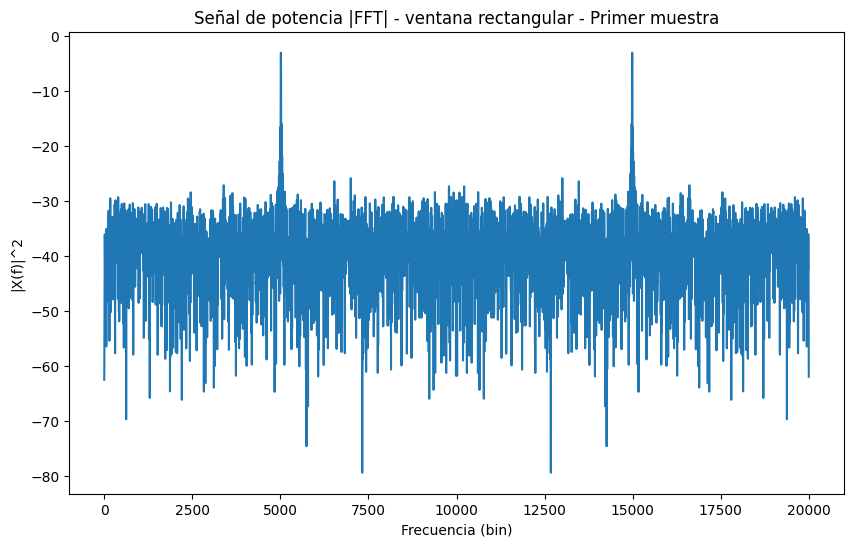

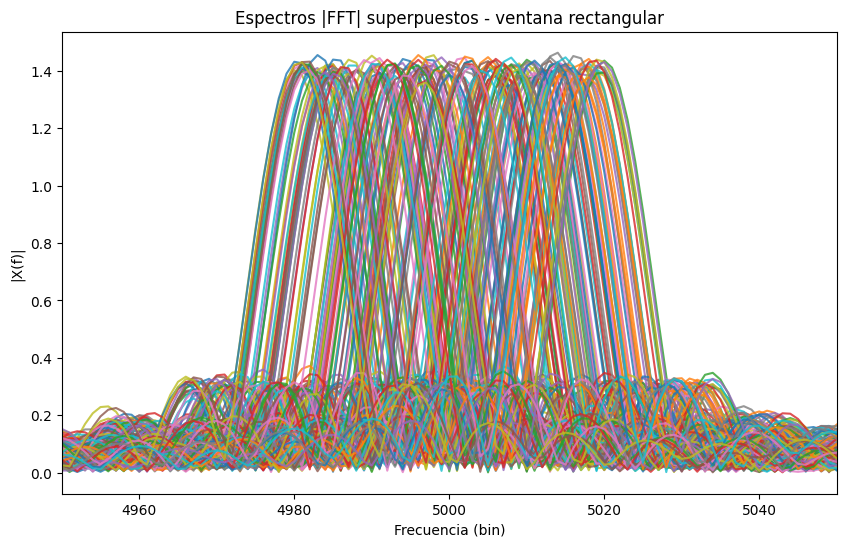

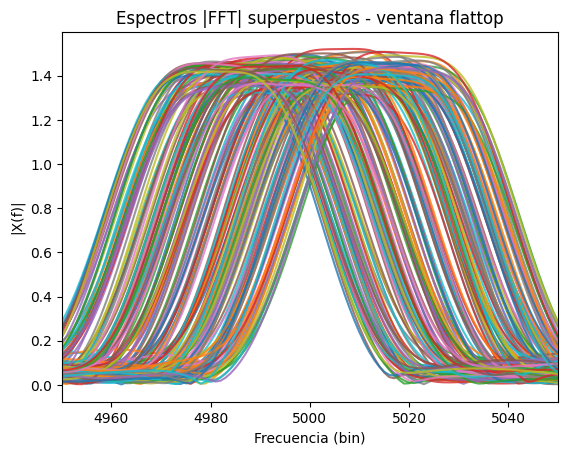

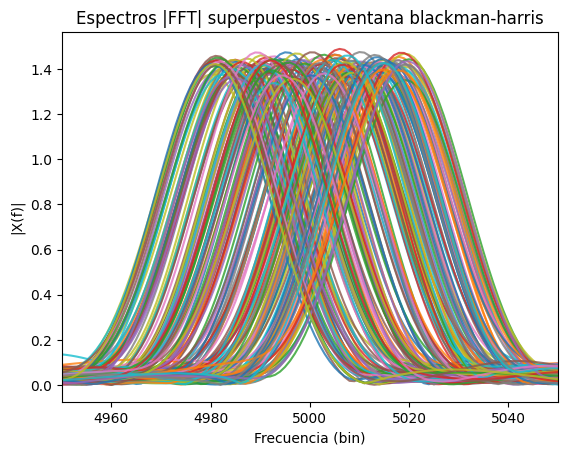

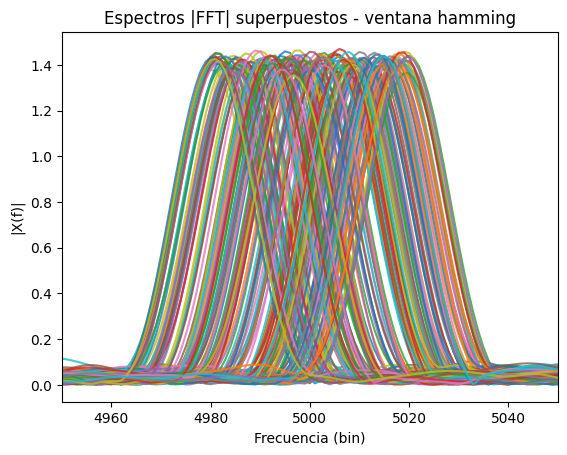

In [203]:
##### Check de primer muestra
PXX = xx_fft_abs["rectangular"][:,0]**2
plt.figure(figsize=(10,6))
plt.plot(10*np.log10(PXX))
plt.title("Señal de potencia |FFT| - ventana rectangular - Primer muestra")
plt.xlabel("Frecuencia (bin)")
plt.ylabel("|X(f)|^2")
plt.show()


##### Gráfico de espectros superpuestos
plt.figure(figsize=(10,6))
for key in xx_fft_abs.keys():
    for i in range(xx_fft_abs[key].shape[1]):
        plt.plot(2*xx_fft_abs[key][:, i], alpha=0.8)
    plt.xlim((f0*N_FFT/fs)*0.99, (f0*N_FFT/fs)*1.01)
    plt.title(f"Espectros |FFT| superpuestos - ventana {key}")
    plt.xlabel("Frecuencia (bin)")
    plt.ylabel("|X(f)|")
    plt.show()


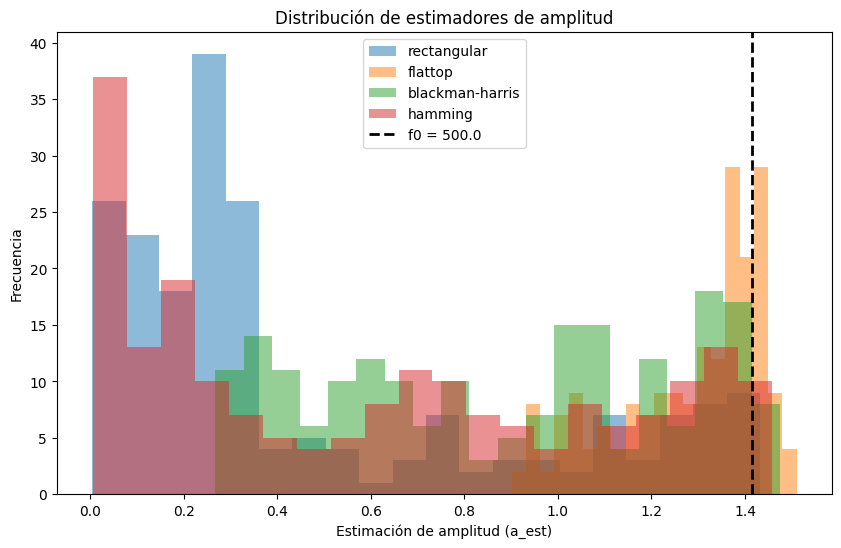

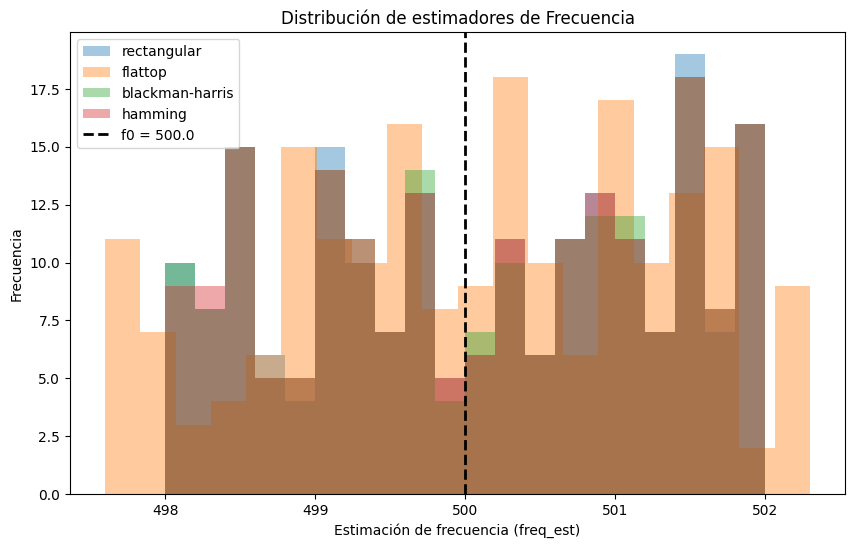

In [204]:
##### Histograma de estimación de energía
fig, ax = plt.subplots(figsize=(10,6))

bins = 20 
alpha = .5

for key in a_est.keys():
    ax.hist(a_est[key], bins=bins, alpha=alpha, label=key)
ax.axvline(vmax, linestyle="--", linewidth=2, label=f"f0 = {f0}", color="black")

ax.set_xlabel("Estimación de amplitud (a_est)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de estimadores de amplitud")
ax.legend()
plt.show()

##### Histograma de estimación de frecuencia
fig, ax = plt.subplots(figsize=(10,6))
bins = 20 
alpha = .4
for key in freq_est.keys():
    ax.hist(freq_est[key], bins=bins, alpha=alpha, label=key)
ax.axvline(f0, linestyle="--", linewidth=2, label=f"f0 = {f0}", color="black")

ax.set_xlabel("Estimación de frecuencia (freq_est)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de estimadores de Frecuencia")
ax.legend()
plt.show()

In [205]:
print("\n" + "="*80)
print(f"{'Ventana':<15} |{'Sesgo a':>15} {'Varianza a':>15} {'Sesgo freq':>15} {'Varianza freq':>15}")
print("="*80)
for key in sesgo_a.keys():
    print(
        f"{key:<15} |"
        f"{sesgo_a[key]:>15.3g} "
        f"{var_a[key]:>15.3g} "
        f"{sesgo_freq[key]:>15.3g} "
        f"{var_freq[key]:>15.3g} "
    )
print("="*80)


Ventana         |        Sesgo a      Varianza a      Sesgo freq   Varianza freq
rectangular     |          0.941           0.182          0.0104          0.0854 
flattop         |          0.106          0.0193         0.00539           0.139 
blackman-harris |          0.481           0.117          0.0154          0.0853 
hamming         |          0.761           0.212          0.0104          0.0854 
